# Student Credit Risk Prediction using Logistic Regression

## End-to-End Machine Learning Pipeline

### Objective
Develop a Logistic Regression model to predict student loan default risk using academic, financial, behavioral, and engineered risk indicators.

### Problem Statement
Educational institutions and lenders often face challenges in identifying students who may struggle to repay educational loans. Early identification of high-risk borrowers enables better financial planning, risk mitigation, and targeted support interventions.

### Model
Logistic Regression (Binary Classification)

### Target Variable
default_flag

0 = Non-default
1 = Default

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Phase 1 - Data Loading & Validation

## Objective
Load the dataset and verify its structure before model development.

## Validation Checks
- Dataset dimensions
- Feature availability
- Data types
- Target distribution

## Dataset
master_v6_post_eda.csv

In [7]:
df = pd.read_csv("master_v6_post_eda.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape:
(21000, 38)

Columns:
['student_id', 'synthetic_age', 'enrollment_type', 'academic_year', 'major_category', 'gpa_direction', 'credit_hours_current', 'semesters_enrolled', 'expected_total_semesters', 'remaining_semesters', 'monthly_inflow_mean', 'cash_flow_cv', 'aid_disbursement_flag', 'aid_amount', 'estimated_tuition', 'estimated_living_cost', 'synthetic_debt_load', 'campus_employment', 'gig_income_flag', 'bill_payment_rate', 'savings_behavior', 'subscription_count', 'prior_delinquency', 'application_week', 'semester_phase', 'academic_calendar_flag', 'ecs', 'gdi', 'acr', 'cfri', 'opr', 'tgb', 'spra', 'sei', 'default_probability', 'default_flag', 'credit_bin', 'synthetic_anomaly_flag']


# Phase 2 - Data Preprocessing

## Objective
Prepare the dataset for Logistic Regression training.

## Steps
- Remove identifier columns
- Remove leakage variables
- Encode categorical features
- Prepare features and target variable

## Removed Columns
- student_id
- default_probability

In [8]:
drop_cols = [
    "student_id",
    "default_probability"
]

df = df.drop(columns=drop_cols)

print("Shape after preprocessing:")
print(df.shape)

Shape after preprocessing:
(21000, 36)


In [9]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Encoding Complete")

Encoding Complete


# Phase 3 - Feature Selection

## Objective
Select the features required for model training.

## Features Used
- Academic indicators
- Financial indicators
- Behavioral indicators
- Engineered risk indicators

## Target Variable
default_flag

In [10]:
X = df.drop("default_flag", axis=1)
y = df["default_flag"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (21000, 35)
Target Shape: (21000,)


In [ ]:
yep same output


# Phase 4 - Logistic Regression Model Training

## Objective
Train a Logistic Regression classifier to predict student loan default risk.

## Why Logistic Regression?

- Simple and interpretable baseline model
- Produces probability estimates
- Computationally efficient
- Widely used in credit-risk analytics

## Training Procedure

1. Train-Test Split
2. Feature Standardization
3. Logistic Regression Training

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Set Shape: (16800, 35)
Testing Set Shape: (4200, 35)

Training Target Distribution:
default_flag
0    16254
1      546
Name: count, dtype: int64

Testing Target Distribution:
default_flag
0    4064
1     136
Name: count, dtype: int64


## Feature Standardization

Logistic Regression is sensitive to differences in feature scales.
Therefore, all features are standardized using StandardScaler so that
each feature contributes proportionally during model optimization.

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


In [13]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


# Phase 5 - Model Evaluation

## Objective
Evaluate the performance of the Logistic Regression model in predicting student loan default risk.

## Evaluation Metrics

- Classification Report
- Confusion Matrix
- ROC-AUC Score

These metrics assess the model's ability to distinguish between default and non-default cases.

In [14]:
y_pred = lr_model.predict(X_test_scaled)

y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [15]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4064
           1       0.50      0.07      0.13       136

    accuracy                           0.97      4200
   macro avg       0.73      0.54      0.56      4200
weighted avg       0.95      0.97      0.96      4200



Confusion Matrix:
[[4054   10]
 [ 126   10]]


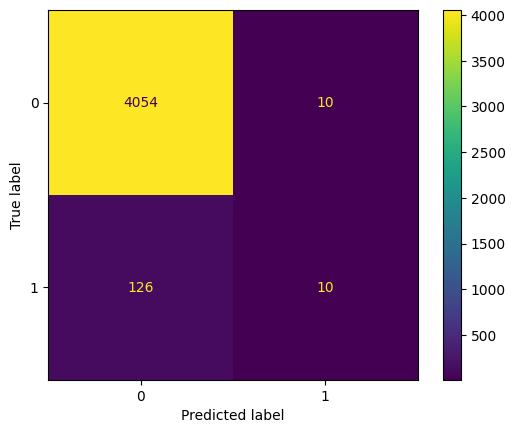

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()
plt.show()

In [17]:
print("ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

ROC-AUC Score:
0.8452770379805465


# Phase 6 - Model Explainability

## Objective
Analyze Logistic Regression coefficients to understand how different features influence default prediction.

## Interpretation

- Positive coefficients increase the probability of default.
- Negative coefficients decrease the probability of default.
- Larger coefficient magnitudes indicate stronger influence on model predictions.

## Benefits

- High interpretability
- Identifies major risk drivers
- Explains the direction of feature influence
- Useful for credit-risk decision-making

In [18]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef_df.round(4))

                     Feature  Coefficient
31                      spra       0.4193
21         prior_delinquency       0.4063
8        remaining_semesters       0.1436
3             major_category       0.1297
14     estimated_living_cost       0.1274
27                       acr       0.1273
2              academic_year       0.1221
10              cash_flow_cv       0.0952
20        subscription_count       0.0703
30                       tgb       0.0670
16         campus_employment       0.0378
24    academic_calendar_flag       0.0339
23            semester_phase       0.0290
13         estimated_tuition       0.0144
0              synthetic_age       0.0108
19          savings_behavior       0.0094
22          application_week       0.0079
7   expected_total_semesters      -0.0011
17           gig_income_flag      -0.0049
34    synthetic_anomaly_flag      -0.0101
33                credit_bin      -0.0107
15       synthetic_debt_load      -0.0292
4              gpa_direction      

In [19]:
print("Top Features Increasing Default Risk:\n")
print(coef_df.head(10).round(4))

Top Features Increasing Default Risk:

                  Feature  Coefficient
31                   spra       0.4193
21      prior_delinquency       0.4063
8     remaining_semesters       0.1436
3          major_category       0.1297
14  estimated_living_cost       0.1274
27                    acr       0.1273
2           academic_year       0.1221
10           cash_flow_cv       0.0952
20     subscription_count       0.0703
30                    tgb       0.0670


In [20]:
print("Top Features Reducing Default Risk:\n")
print(coef_df.tail(10).round(4))

Top Features Reducing Default Risk:

                  Feature  Coefficient
28                   cfri      -0.0952
9     monthly_inflow_mean      -0.1076
29                    opr      -0.1244
18      bill_payment_rate      -0.1244
6      semesters_enrolled      -0.1628
25                    ecs      -0.1733
11  aid_disbursement_flag      -0.2827
32                    sei      -0.2854
12             aid_amount      -0.3079
26                    gdi      -0.4712


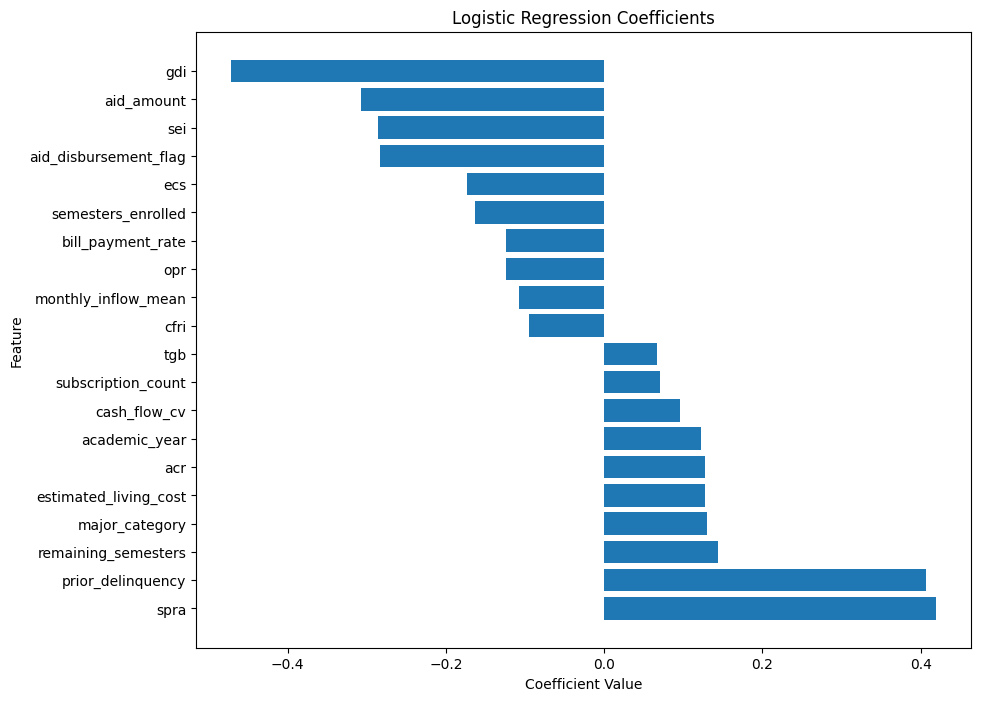

In [21]:
top_coef = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
])

plt.figure(figsize=(10,8))
plt.barh(
    top_coef["Feature"],
    top_coef["Coefficient"]
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

## Phase 6 Findings

The Logistic Regression coefficients indicate that default risk is influenced by both financial vulnerability and protective support factors.

### Major Risk Drivers
- SPRA (0.4193)
- Prior Delinquency (0.4063)
- Remaining Semesters (0.1436)

### Major Protective Factors
- GDI (-0.4712)
- Aid Amount (-0.3079)
- SEI (-0.2854)

The coefficient analysis demonstrates that students with prior payment issues, higher academic expenses, and elevated risk scores are more likely to default, whereas financial aid, better socio-economic conditions, and stable financial indicators reduce default probability.

Interestingly, SPRA, GDI, and SEI were also identified as influential features in the XGBoost model, indicating consistency across different machine learning approaches.

# Phase 7 - Fairness & Stability Analysis

## Objective
Evaluate prediction behavior, error distribution, and model stability on unseen data.

## Analysis Performed
- Prediction Distribution
- False Positives
- False Negatives
- Error Analysis

This phase helps determine whether the model is consistently predicting both classes and identifies areas where the model struggles.

In [22]:
pred_dist = pd.Series(y_pred).value_counts()

print("Prediction Distribution:")
print(pred_dist)

Prediction Distribution:
0    4180
1      20
Name: count, dtype: int64


In [23]:
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 10
False Negatives: 126


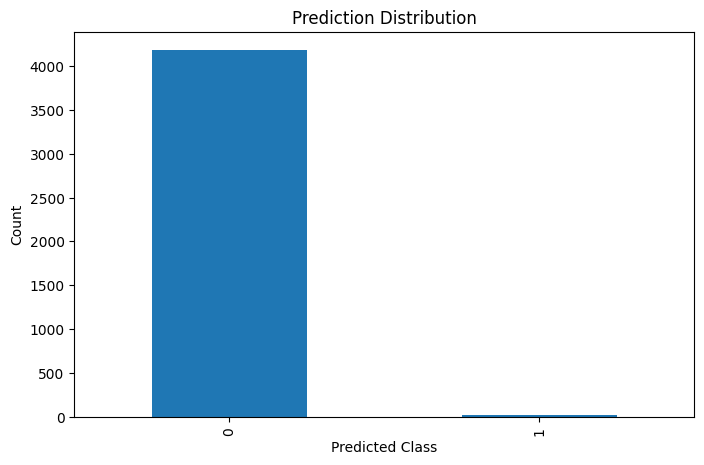

In [24]:
pred_dist.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()

## Phase 7 Findings

The Logistic Regression model exhibited stable performance on the test dataset but showed strong bias toward the majority class.

### Observations
- Majority of predictions belonged to the non-default class.
- Only a small number of transactions were predicted as defaults.
- False negatives were substantially higher than false positives.

### Implications
The model is conservative in predicting defaults and tends to miss a considerable portion of high-risk students. This behavior is primarily due to class imbalance in the dataset.

### Future Improvements
- Class weighting
- SMOTE-based resampling
- Decision threshold tuning
- Cost-sensitive learning approaches

# Phase 8 - Prediction Pipeline

## Workflow

Student Information
↓
Data Preprocessing
↓
Feature Encoding
↓
Feature Standardization
↓
Logistic Regression Model
↓
Default Probability Estimation
↓
Risk Classification

In [25]:
sample_student = X_test.iloc[[0]]

sample_student_scaled = scaler.transform(sample_student)

prediction = lr_model.predict(sample_student_scaled)
probability = lr_model.predict_proba(sample_student_scaled)

print("Predicted Class:", prediction[0])
print("Prediction Probability:", probability)

Predicted Class: 0
Prediction Probability: [[0.97192824 0.02807176]]


# Phase 9 - Nemotron Comparison

## Objective

Compare the Logistic Regression model against a Nemotron-based approach.

## Comparison Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Explainability
- Computational Cost
- Inference Time

## Status
Nemotron implementation and prompt engineering will be documented in a separate notebook. This section will be updated after the Nemotron evaluation pipeline is finalized.